In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report
import joblib

# The 5 Basic Models
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

# Single source of truth for dataset location (used by multiple cells)
DATA_PATH = "enriched_climate_health_dataset.csv"

def main():
    print("Loading dataset...")
    df = pd.read_csv(DATA_PATH)

    print("Preprocessing data (Raw Features Mode)...")
    # Dropping only strictly useless metadata
    cols_to_drop = ['record_id', 'country_code']
    df = df.drop(columns=cols_to_drop)

    # Extract date logic and drop the raw string to make it readable for all machine learning models
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df = df.drop(columns=['date'])

    target_col = 'heat_related_admissions'

    # Temporal split: Train on 2015-2023, Test on 2024 (Discard 2025 rows)
    train_df = df[df['year'] <= 2023].copy()
    test_df  = df[df['year'] == 2024].copy()
    print(f"Temporal Split -> Train: 2015-2023 ({len(train_df)} rows), Test: 2024 ({len(test_df)} rows)")

    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]
    X_test  = test_df.drop(columns=[target_col])
    y_test  = test_df[target_col]

    categorical_features = ['country_name','region', 'income_level', 'month']
    numerical_features = [col for col in X_train.columns if col not in categorical_features]

    print("Setting up Preprocessor...")
    # Standard configuration to instantly convert raw inputs into scaled, model-ready math arrays
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ])

    print("=== STAGE 1 CLASSIFIER (Heat Event vs No Event) ===")
    # Stage 1: predict whether admissions are zero or non-zero
    y_train_cls = (y_train > 0).astype(int)
    y_test_cls  = (y_test  > 0).astype(int)

    stage1_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1))
    ])
    stage1_pipeline.fit(X_train, y_train_cls)
    stage1_preds = stage1_pipeline.predict(X_test)
    stage1_train_preds = stage1_pipeline.predict(X_train)
    
    print("Classification Report on 2024 Test Set:")
    print(classification_report(y_test_cls, stage1_preds))
    joblib.dump(stage1_pipeline, 'streamlit_model_stage1_classifier.pkl')
    print("Saved Stage 1 Classifier completely to streamlit_model_stage1_classifier.pkl\n")

    # Stage 2: train regressors only on non-zero admission rows
    print("Filtering training data for Stage 2 Regressor (non-zero only)...")
    mask_train_nz = y_train > 0
    X_train_nz = X_train[mask_train_nz]
    y_train_nz = y_train[mask_train_nz]
    print(f"Non-zero training samples for Stage 2: {len(X_train_nz)}\n")

    # For secondary metrics testing:
    mask_test_nz = y_test > 0
    X_test_nz = X_test[mask_test_nz]
    y_test_nz = y_test[mask_test_nz]

    # Initialize the 5 models explicitly
    models = {
        'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        'Decision Tree': DecisionTreeRegressor(random_state=42),
        'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
        'CatBoost': CatBoostRegressor(random_state=42, verbose=0), # verbose=0 suppresses the huge output
        'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1)
    }

    results = []

    for name, model in models.items():
        print(f"Training {name} (Stage 2)...")
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('regressor', model)
        ])
        
        # Fit the regressor model pipeline on non-zero data
        pipeline.fit(X_train_nz, y_train_nz)
        
        # Get Training predictions for Stage 2
        y_train_pred_nz = pipeline.predict(X_train_nz)
        train_r2_nz = r2_score(y_train_nz, y_train_pred_nz)
        train_rmse_nz = np.sqrt(mean_squared_error(y_train_nz, y_train_pred_nz))

        # Evaluate using the combined hurdle prediction on the testing set
        stage2_preds = pipeline.predict(X_test)
        final_preds = np.where(stage1_preds == 1, stage2_preds, 0.0)

        # Evaluate combined system on the training set
        stage2_train_preds_full = pipeline.predict(X_train)
        final_train_preds = np.where(stage1_train_preds == 1, stage2_train_preds_full, 0.0)

        # Primary metrics: combined system
        train_r2 = r2_score(y_train, final_train_preds)
        test_r2 = r2_score(y_test, final_preds)
        combined_discrepancy = abs(train_r2 - test_r2)
        
        train_rmse = np.sqrt(mean_squared_error(y_train, final_train_preds))
        test_rmse = np.sqrt(mean_squared_error(y_test, final_preds))
        combined_rmse_discrepancy = abs(train_rmse - test_rmse)

        # Secondary metric: Stage 2 regressor on non-zero test rows only
        stage2_preds_nz = pipeline.predict(X_test_nz)
        stage2_r2_nz = r2_score(y_test_nz, stage2_preds_nz)
        stage2_rmse_nz = np.sqrt(mean_squared_error(y_test_nz, stage2_preds_nz))
        
        discrepancy_nz = abs(train_r2_nz - stage2_r2_nz)
        stage2_rmse_discrepancy = abs(train_rmse_nz - stage2_rmse_nz)
        
        print(f"[{name}] Combined Train R2: {train_r2:.4f} | Combined Test R2: {test_r2:.4f} | Combined Discrepancy: {combined_discrepancy:.4f} | Combined Test RMSE: {test_rmse:.4f}")
        print(f"[{name}] Stage 2 (NZ) Train R2: {train_r2_nz:.4f} | Stage 2 (NZ) Test R2: {stage2_r2_nz:.4f} | Stage 2 (NZ) Discrepancy: {discrepancy_nz:.4f}\n")
        
        # Export entirely self-contained models for the Streamlit UI to easily load
        filename = f"streamlit_model_stage2_{name.replace(' ', '_').lower()}.pkl"
        joblib.dump(pipeline, filename)
        print(f"Saved Stage 2 {name} completely to {filename}\n")
        
        results.append({
            'Model': name, 
            'Combined_Train_R2': train_r2,
            'Combined_Test_R2': test_r2,
            'Combined_Discrepancy': combined_discrepancy,
            'Combined_Train_RMSE': train_rmse,
            'Combined_Test_RMSE': test_rmse,
            'Combined_RMSE_Discrepancy': combined_rmse_discrepancy,
            'Stage2_Train_R2': train_r2_nz, 
            'Stage2_Test_R2': stage2_r2_nz, 
            'Stage2_Discrepancy': discrepancy_nz,
            'Stage2_Train_RMSE': train_rmse_nz, 
            'Stage2_Test_RMSE': stage2_rmse_nz,
            'Stage2_RMSE_Discrepancy': stage2_rmse_discrepancy
        })

    # Summary table output so we can compare the raw model capabilities
    print("=== FINAL MODEL COMPARISON ===")
    results_df = pd.DataFrame(results).sort_values(by='Combined_Test_R2', ascending=False)
    print(results_df.to_string(index=False))

    # Saving the results table to a txt file for logging purposes
    results_df.to_csv("models_comparison_v2.csv", index=False)

if __name__ == "__main__":
    main()

Loading dataset...
Preprocessing data (Raw Features Mode)...
Temporal Split -> Train: 2015-2023 (11750 rows), Test: 2024 (1300 rows)
Setting up Preprocessor...
=== STAGE 1 CLASSIFIER (Heat Event vs No Event) ===


c:\Users\admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification Report on 2024 Test Set:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       631
           1       0.92      0.90      0.91       669

    accuracy                           0.91      1300
   macro avg       0.91      0.91      0.91      1300
weighted avg       0.91      0.91      0.91      1300

Saved Stage 1 Classifier completely to streamlit_model_stage1_classifier.pkl

Filtering training data for Stage 2 Regressor (non-zero only)...
Non-zero training samples for Stage 2: 5918

Training LightGBM (Stage 2)...


c:\Users\admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] Combined Train R2: 0.9094 | Combined Test R2: 0.8247 | Combined Discrepancy: 0.0847 | Combined Test RMSE: 4.0452
[LightGBM] Stage 2 (NZ) Train R2: 0.8531 | Stage 2 (NZ) Test R2: 0.6931 | Stage 2 (NZ) Discrepancy: 0.1600

Saved Stage 2 LightGBM completely to streamlit_model_stage2_lightgbm.pkl

Training Decision Tree (Stage 2)...
[Decision Tree] Combined Train R2: 0.9713 | Combined Test R2: 0.6260 | Combined Discrepancy: 0.3453 | Combined Test RMSE: 5.9083
[Decision Tree] Stage 2 (NZ) Train R2: 1.0000 | Stage 2 (NZ) Test R2: 0.2949 | Stage 2 (NZ) Discrepancy: 0.7051

Saved Stage 2 Decision Tree completely to streamlit_model_stage2_decision_tree.pkl

Training XGBoost (Stage 2)...
[XGBoost] Combined Train R2: 0.9638 | Combined Test R2: 0.8140 | Combined Discrepancy: 0.1498 | Combined Test RMSE: 4.1663
[XGBoost] Stage 2 (NZ) Train R2: 0.9640 | Stage 2 (NZ) Test R2: 0.6758 | Stage 2 (NZ) Discrepancy: 0.2882

Saved Stage 2 XGBoost completely to streamlit_model_stage2_xgboost.pkl



### How Metrics are Derived: Combined vs. Stage 2 R²

**Combined Train/Test R²** evaluates the end-to-end performance of our two-stage "hurdle" system across *all* data, including days with zero admissions. The final prediction is formed by:
1. **Stage 1 (Classifier)**: Predicts whether an event occurred (0 or 1).
2. **Stage 2 (Regressor)**: If Stage 1 predicts 1, we use Stage 2 to estimate the actual number of admissions. If Stage 1 predicts 0, the final prediction is forced to exactly 0.
The Combined R² compares these final two-step predictions against the full dataset's true values.

**Stage 2 (NZ) Train/Test R²** evaluates the regression model strictly on the subset of data where heat-related admissions *actually occurred* (Non-Zero / NZ days). It measures how accurately the model predicts the magnitude of an event, completely isolating the regressor's performance from the Stage 1 classifier and ignoring days with zero admissions.

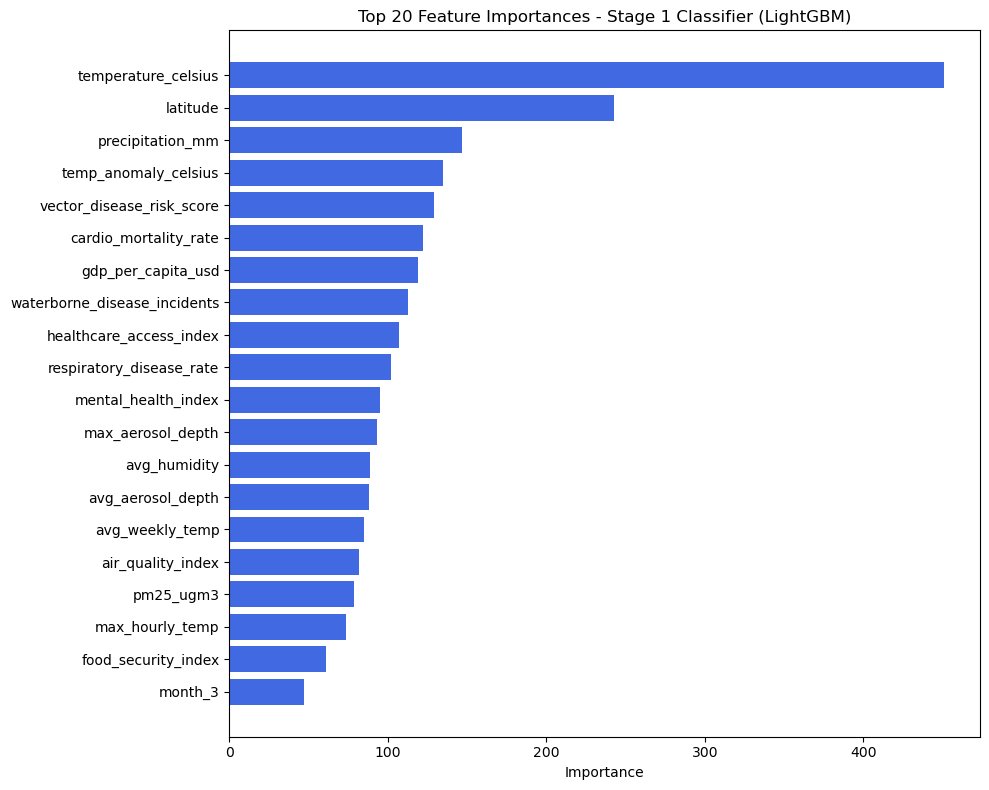

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Load the saved Stage 1 LightGBM pipeline
lgbm_stage1_pipeline = joblib.load('streamlit_model_stage1_classifier.pkl')

# Extract the fitted LightGBM model and preprocessor
lgbm_stage1_model = lgbm_stage1_pipeline.named_steps['classifier']
preprocessor = lgbm_stage1_pipeline.named_steps['preprocessor']

# Get feature names from the preprocessor
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][1].get_feature_names_out(preprocessor.transformers_[1][2]).tolist()
all_features = list(num_features) + cat_features

# Get feature importances
importances_stage1 = lgbm_stage1_model.feature_importances_

# Create DataFrame and sort
feat_imp_stage1 = pd.DataFrame({'Feature': all_features, 'Importance': importances_stage1})
feat_imp_stage1 = feat_imp_stage1.sort_values(by='Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feat_imp_stage1['Feature'][::-1], feat_imp_stage1['Importance'][::-1], color='royalblue')
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances - Stage 1 Classifier (LightGBM)')
plt.tight_layout()
plt.show()

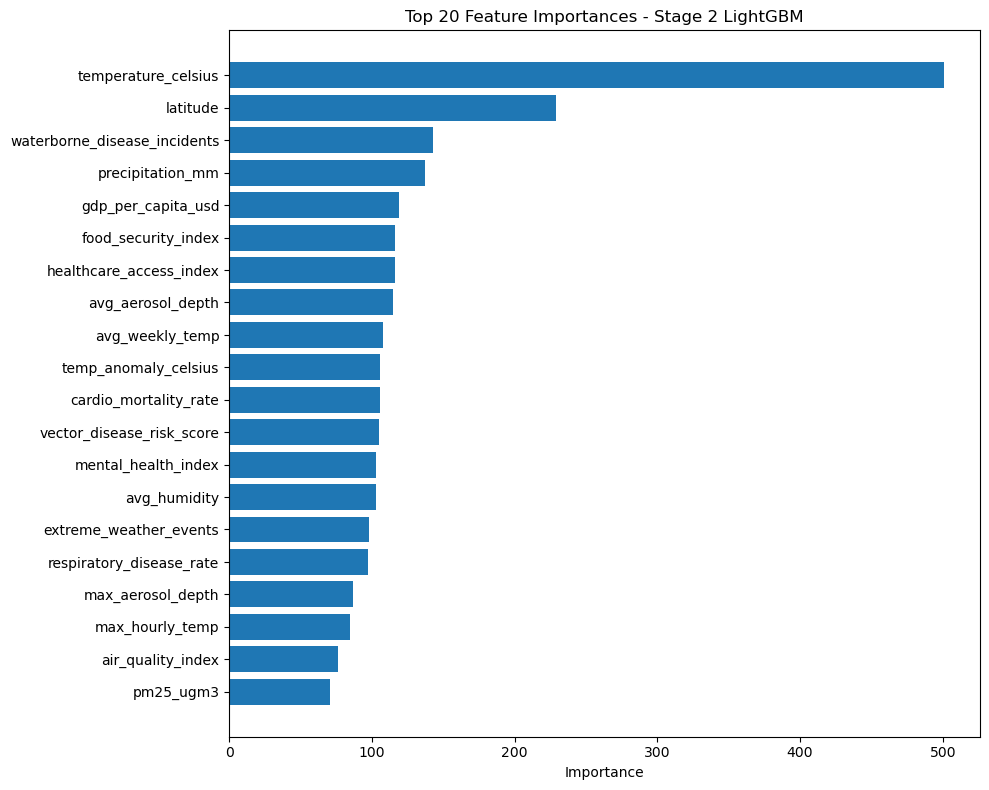

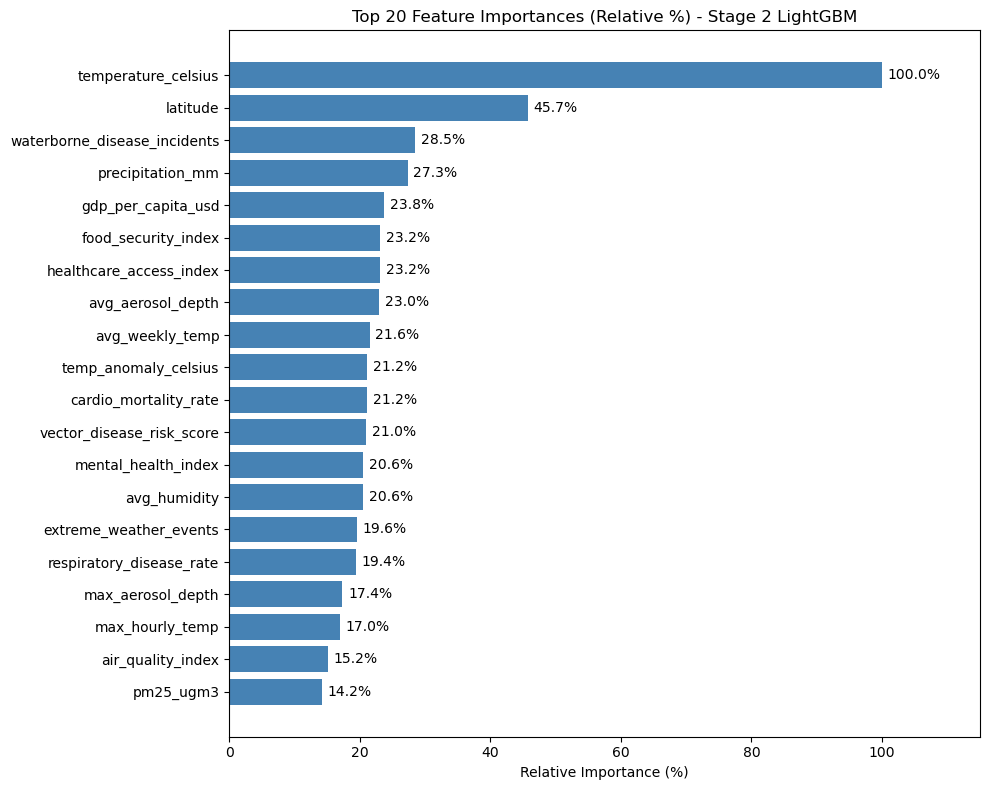

In [9]:
import matplotlib.pyplot as plt

# Load the saved Stage 2 LightGBM pipeline
lgbm_pipeline = joblib.load('streamlit_model_stage2_lightgbm.pkl')

# Extract the fitted LightGBM model and feature names
lgbm_model = lgbm_pipeline.named_steps['regressor']
preprocessor = lgbm_pipeline.named_steps['preprocessor']

# Get feature names from the preprocessor
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][1].get_feature_names_out(preprocessor.transformers_[1][2]).tolist()
all_features = list(num_features) + cat_features

# Get feature importances
importances = lgbm_model.feature_importances_

# Sort by importance
feat_imp = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(20)

# Plot absolute importances
plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances - Stage 2 LightGBM')
plt.tight_layout()
plt.show()

# Calculate relative percentages (Max importance = 100%)
max_importance = feat_imp['Importance'].max()
feat_imp['Relative_Importance'] = (feat_imp['Importance'] / max_importance) * 100

# Plot relative percentages
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(feat_imp['Feature'][::-1], feat_imp['Relative_Importance'][::-1], color='steelblue')

# Add the specific percentage labels right next to each bar
ax.bar_label(bars, fmt='%.1f%%', padding=4)

# Expand x-axis limit so the 100.0% label is not cut off
ax.set_xlim(0, 115)

plt.xlabel('Relative Importance (%)')
plt.title('Top 20 Feature Importances (Relative %) - Stage 2 LightGBM')
plt.tight_layout()
plt.show()

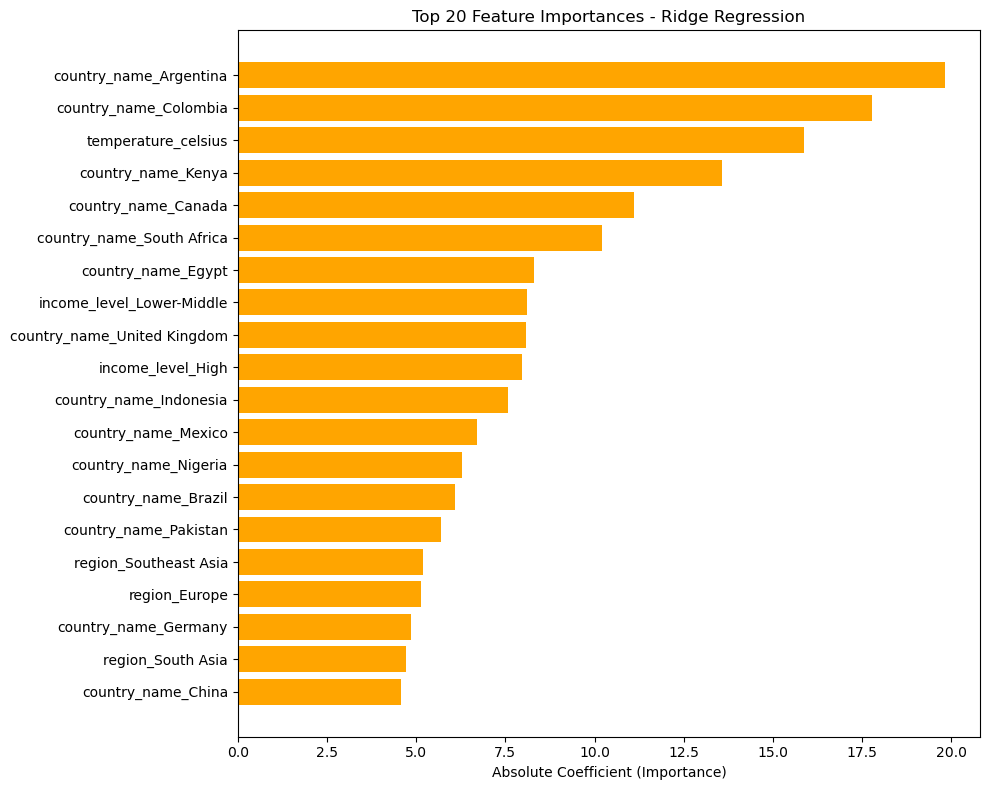

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Load the saved stage 2 Ridge Regression pipeline
ridge_pipeline = joblib.load('streamlit_model_stage2_ridge_regression.pkl')
ridge_model = ridge_pipeline.named_steps['regressor']
preprocessor = ridge_pipeline.named_steps['preprocessor']

# Get feature names
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][1].get_feature_names_out(preprocessor.transformers_[1][2]).tolist()
all_features = list(num_features) + cat_features

# Get absolute coefficients as importance
importances = abs(ridge_model.coef_)

# Sort by importance
feat_imp = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1], color='orange')
plt.xlabel('Absolute Coefficient (Importance)')
plt.title('Top 20 Feature Importances - Ridge Regression')
plt.tight_layout()
plt.show()

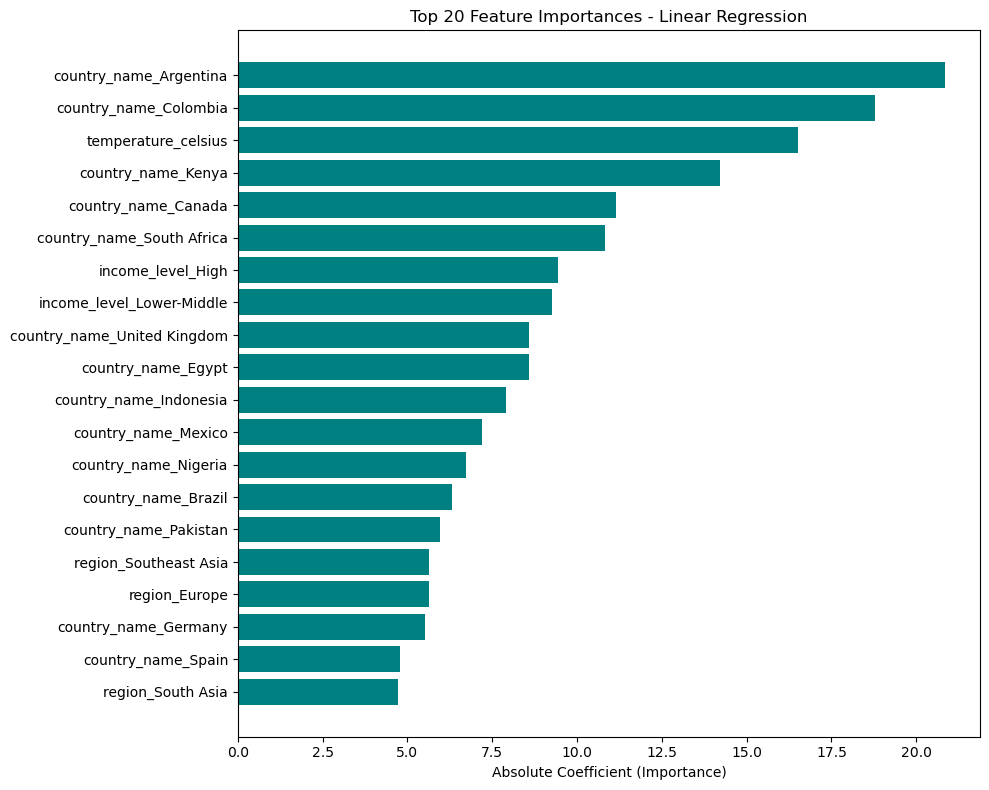

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Load the saved stage 2 Linear Regression pipeline
lr_pipeline = joblib.load('streamlit_model_stage2_linear_regression.pkl')
lr_model = lr_pipeline.named_steps['regressor']
preprocessor = lr_pipeline.named_steps['preprocessor']

# Get feature names
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][1].get_feature_names_out(preprocessor.transformers_[1][2]).tolist()
all_features = list(num_features) + cat_features

# Get absolute coefficients as importance
importances = abs(lr_model.coef_)

# Sort by importance
feat_imp = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1], color='teal')
plt.xlabel('Absolute Coefficient (Importance)')
plt.title('Top 20 Feature Importances - Linear Regression')
plt.tight_layout()
plt.show()

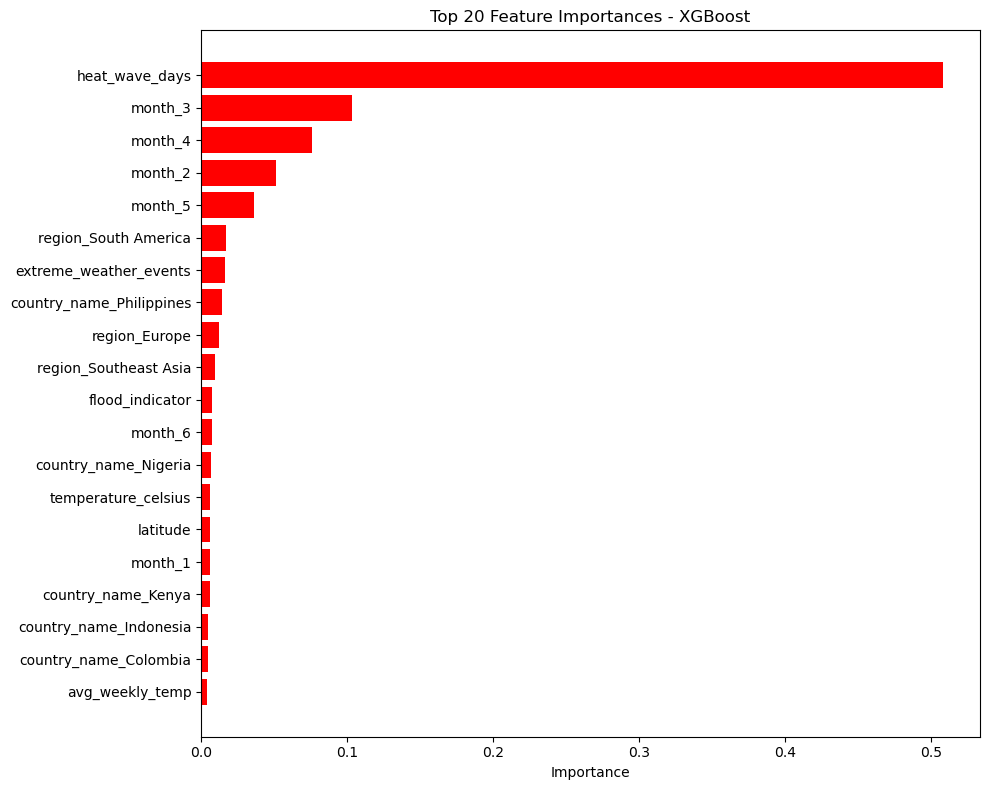

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Load the saved stage 2 XGBoost pipeline
xgb_pipeline = joblib.load('streamlit_model_stage2_xgboost.pkl')
xgb_model = xgb_pipeline.named_steps['regressor']
preprocessor = xgb_pipeline.named_steps['preprocessor']

# Get feature names
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][1].get_feature_names_out(preprocessor.transformers_[1][2]).tolist()
all_features = list(num_features) + cat_features

# Get feature importances
importances = xgb_model.feature_importances_

# Sort by importance
feat_imp = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1], color='red')
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances - XGBoost')
plt.tight_layout()
plt.show()

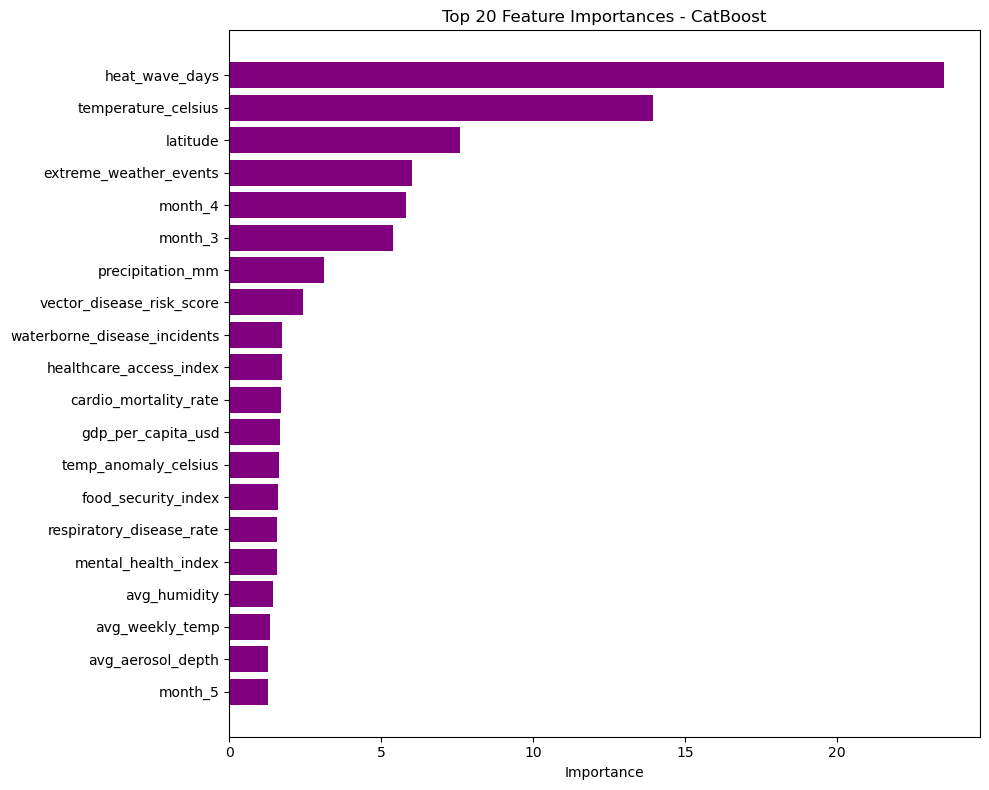

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Load the saved stage 2 CatBoost pipeline
cat_pipeline = joblib.load('streamlit_model_stage2_catboost.pkl')
cat_model = cat_pipeline.named_steps['regressor']
preprocessor = cat_pipeline.named_steps['preprocessor']

# Get feature names
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][1].get_feature_names_out(preprocessor.transformers_[1][2]).tolist()
all_features = list(num_features) + cat_features

# Get feature importances
importances = cat_model.feature_importances_

# Sort by importance
feat_imp = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1], color='purple')
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances - CatBoost')
plt.tight_layout()
plt.show()

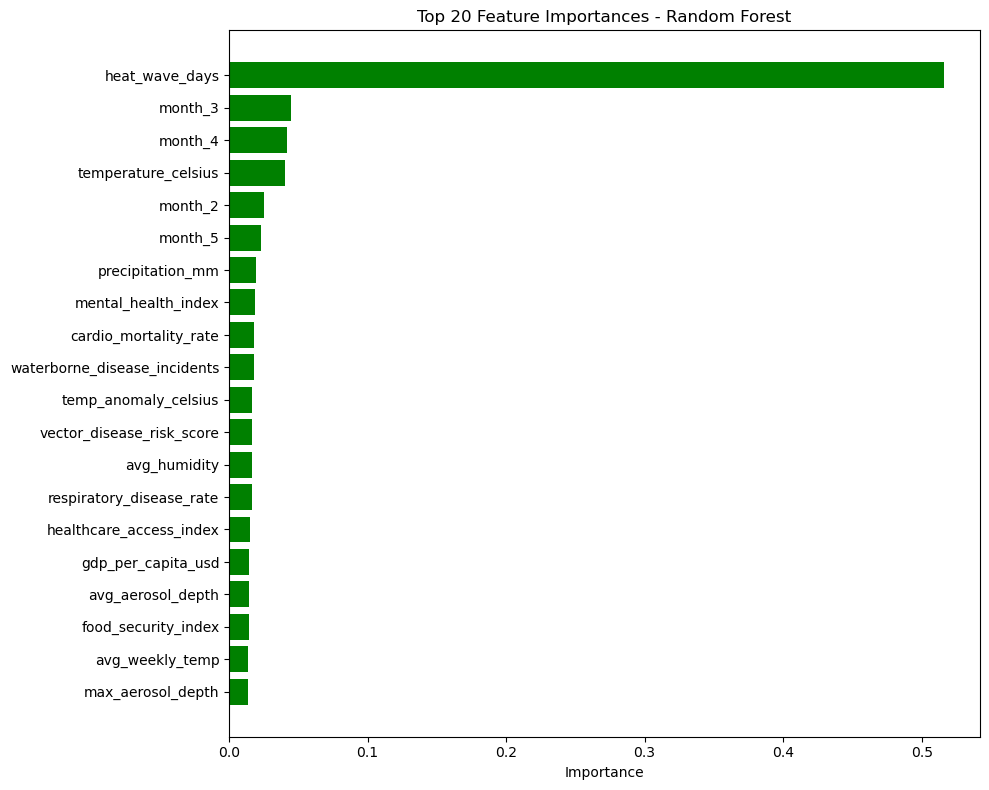

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Load the saved stage 2 Random Forest pipeline
rf_pipeline = joblib.load('streamlit_model_stage2_random_forest.pkl')
rf_model = rf_pipeline.named_steps['regressor']
preprocessor = rf_pipeline.named_steps['preprocessor']

# Get feature names
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][1].get_feature_names_out(preprocessor.transformers_[1][2]).tolist()
all_features = list(num_features) + cat_features

# Get feature importances
importances = rf_model.feature_importances_

# Sort by importance
feat_imp = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1], color='green')
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy import stats

df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

train = df[df['year'] <= 2023]
nz = train[train['heat_related_admissions'] > 0]

rows = []
for country in sorted(nz['country_name'].unique()):
    sub = nz[nz['country_name'] == country]
    train_c = train[train['country_name'] == country]

    # Local P90: extreme relative to this country's own distribution
    local_p90 = sub['heat_related_admissions'].quantile(0.90)
    local_high = sub[sub['heat_related_admissions'] >= local_p90]
    high_per_yr = local_high.groupby('year').size().reindex(range(2015, 2024), fill_value=0)
    slope_high, _, _, _, _ = stats.linregress(high_per_yr.index, high_per_yr.values)

    yearly_mean = sub.groupby('year')['heat_related_admissions'].mean()
    slope_mean, _, _, _, _ = stats.linregress(yearly_mean.index, yearly_mean.values)

    anomaly_by_yr = train_c.groupby('year')['temp_anomaly_celsius'].mean()
    slope_anomaly, _, _, _, _ = stats.linregress(anomaly_by_yr.index, anomaly_by_yr.values)

    rows.append({
        'country': country,
        'region': train_c['region'].mode()[0],
        'income_level': train_c['income_level'].mode()[0],
        'latitude': train_c['latitude'].mean(),
        'longitude': train_c['longitude'].mean(),
        'mean_admissions': sub['heat_related_admissions'].mean(),
        'local_p90_admissions': round(local_p90, 2),
        'admission_slope': round(slope_mean, 4),
        'high_event_slope_local': round(slope_high, 4),
        'anomaly_slope': round(slope_anomaly, 5),
        'healthcare_access': round(train_c['healthcare_access_index'].mean(), 2),
        'gdp_per_capita': round(train_c['gdp_per_capita_usd'].mean(), 0),
        'active_months_per_yr': round(sub.groupby('year')['month'].nunique().mean(), 2),
    })

cdf = pd.DataFrame(rows)

# Cluster on: climate trajectory + locally-anchored health burden trajectory + system capacity
cluster_features = ['anomaly_slope', 'admission_slope', 'high_event_slope_local',
                    'healthcare_access', 'gdp_per_capita']
X = StandardScaler().fit_transform(cdf[cluster_features])
cdf['risk_cluster'] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X)

# Verify mapping by inspecting cluster profiles, then assign labels
# Cluster 0: high admission_slope, low HCA  -> Rising Burden
# Cluster 1: low admission_slope, high HCA  -> Stable & Buffered 
# Cluster 2: negative/flat slope, mid HCA   -> High Exposure - Plateauing
tier_map = {0: 'Rising Burden', 1: 'Stable & Buffered', 2: 'High Exposure - Plateauing'}
cdf['risk_tier'] = cdf['risk_cluster'].map(tier_map)

cdf.to_csv('country_clusters.csv', index=False)
print(cdf[['country', 'risk_tier', 'admission_slope', 'high_event_slope_local',
           'healthcare_access', 'income_level']].sort_values(['risk_tier', 'country']).to_string(index=False))

       country                  risk_tier  admission_slope  high_event_slope_local  healthcare_access income_level
     Argentina High Exposure - Plateauing          -0.1996                 -0.0500              61.73 Upper-Middle
         China High Exposure - Plateauing          -0.0643                 -0.1667              74.42 Upper-Middle
         Egypt High Exposure - Plateauing          -0.0718                 -0.0167              40.64 Lower-Middle
     Indonesia High Exposure - Plateauing          -0.1763                  0.0667              44.71 Lower-Middle
         Kenya High Exposure - Plateauing          -0.1302                 -0.1167              47.64 Lower-Middle
        Mexico High Exposure - Plateauing          -0.0126                 -0.0167              65.14 Upper-Middle
  South Africa High Exposure - Plateauing           0.0104                 -0.1167              73.80 Upper-Middle
      Thailand High Exposure - Plateauing           0.0296                  0.23

c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
